In [1]:
import sys
import pandas as pd
import pickle
import importlib
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments
from pm4py.utils import get_properties

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../../')
sys.path.insert(0, '../../../../../')

# Add path to the other project src to handle imports with dashes in folder names
sys.path.insert(0, '../../../../../probabilistic_suffix_prediction_U-ED-LSTM/src')

In [2]:
# log as csv
event_log_path = '../../../../data/data/DomesticDeclarations_cleaned.csv'
event_log_df = pd.read_csv(event_log_path)

case_id_key='case:concept:name'
activity_key='concept:name'
time_key='time:timestamp'

# split csv data
train_csv_path = '../../../probabilistic_suffix_prediction_U-ED-LSTM/encoded_data_decision/BPIC20_DD/prefix_for_replay/bpic20_DD_all_5_train.csv'
helpdesk_train_df = pd.read_csv(train_csv_path)

val_csv_path = '../../../probabilistic_suffix_prediction_U-ED-LSTM/encoded_data_decision/BPIC20_DD/prefix_for_replay/bpic20_DD_all_5_val.csv'
helpdesk_val_df = pd.read_csv(val_csv_path)

test_csv_path = '../../../probabilistic_suffix_prediction_U-ED-LSTM/encoded_data_decision/BPIC20_DD/prefix_for_replay/bpic20_DD_all_5_test.csv'
helpdesk_test_df = pd.read_csv(test_csv_path)

# get case ids
unique_list_train = helpdesk_train_df[case_id_key].dropna().unique().tolist()
unique_list_val = helpdesk_val_df[case_id_key].dropna().unique().tolist()
case_ids = list(dict.fromkeys(unique_list_train + unique_list_val))
case_ids = sorted(case_ids)
print(case_ids[0:5])

# edit and adjust the dataframe event log
df = event_log_df.copy()
if case_ids is not None:
   df = df[df[case_id_key].isin(set(case_ids))]

rename_map = {}
if case_id_key in df.columns and case_id_key != "case:concept:name":
   rename_map[case_id_key] = "case:concept:name"
if activity_key in df.columns and activity_key != "concept:name":
   rename_map[activity_key] = "concept:name"
if time_key in df.columns and time_key != "time:timestamp":
   rename_map[time_key] = "time:timestamp"

if rename_map:
   df = df.rename(columns=rename_map)

# Ensure timestamp is datetime
if "time:timestamp" in df.columns:
   df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], errors="coerce")

# Sort for determinism (important for trace attribute replication + alignments)
sort_cols = ["case:concept:name"]
if "time:timestamp" in df.columns:
   sort_cols.append("time:timestamp")
df = df.sort_values(sort_cols).reset_index(drop=True)

print(df.head(5))

['declaration 100000', 'declaration 100005', 'declaration 100010', 'declaration 100015', 'declaration 100021']
                         id  org:resource                concept:name  \
0          st_step 100004_0  STAFF MEMBER       Declaration SUBMITTED   
1          st_step 100003_0  STAFF MEMBER        Declaration APPROVED   
2          st_step 100002_0  STAFF MEMBER  Declaration FINAL_APPROVED   
3  dd_declaration 100000_19        SYSTEM             Request Payment   
4  dd_declaration 100000_20        SYSTEM             Payment Handled   

       time:timestamp        org:role             case:id   case:concept:name  \
0 2018-01-30 09:20:07        EMPLOYEE  declaration 100000  declaration 100000   
1 2018-02-07 09:58:46  ADMINISTRATION  declaration 100000  declaration 100000   
2 2018-02-08 10:59:05      SUPERVISOR  declaration 100000  declaration 100000   
3 2018-02-09 12:42:49       UNDEFINED  declaration 100000  declaration 100000   
4 2018-02-12 17:31:20       UNDEFINED  declar

In [3]:
# Minimal sanity check: timestamps must be datetime + sorted within each case for event_elapsed_time
case_col = "case:concept:name"
ts_col = "time:timestamp"

if ts_col in df.columns:
    is_dt = pd.api.types.is_datetime64_any_dtype(df[ts_col])
    print("time:timestamp is datetime:", is_dt)
    if not is_dt:
        print("WARNING: time:timestamp is not datetime; event_elapsed_time will be wrong")

if case_col in df.columns and ts_col in df.columns:
    neg = df.groupby(case_col)[ts_col].diff() < pd.Timedelta(0)
    n_bad = int(neg.fillna(False).sum())
    print("Out-of-order timestamps (within case):", n_bad)
    if n_bad > 0:
        print("WARNING: df is not sorted within cases; sort upstream before mining")

time:timestamp is datetime: True
Out-of-order timestamps (within case): 0


In [4]:
# import petri net 
petri_net_path = '../../../probabilistic_suffix_prediction_U-ED-LSTM/encoded_data_decision/BPIC20_DD/prefix_for_replay/petri_net/bpic20_DD.pkl'
with open(petri_net_path, 'rb') as f:
    net, im, fm = pickle.load(f)

In [5]:
# Input: GenerateTransitionGuards Algorithm
# - N = (P,T,F): A Petri net without data
petri_net=(net, im, fm)

# petri_net = (net, im, fm)
net, im, fm = petri_net

# - EL: event log
event_log_df = df

# - A: A multiset of optimal control-flow alignments of N and an event log
params = get_properties(event_log_df)  # keeps case_id/activity/timestamp keys, etc.
params["ret_tuple_as_trans_desc"] = True  # <--- key part

aligned_traces = alignments.apply(event_log_df, net, im, fm, parameters=params)
# get alignments:
alignments = [align_dict['alignment'] for align_dict in aligned_traces]
print(alignments[0:5])

# attributes to be considered for decision mining:
dynamic_attributes = ['org:resource',
                      'org:role',
                      'event_elapsed_time']

static_attributes = ['case:Amount']


aligning log, completed variants ::   0%|          | 0/74 [00:00<?, ?it/s]

[[(('>>', 'skip_1'), ('>>', None)), (('>>', 'tauSplit_3'), ('>>', None)), (('>>', 'skip_5'), ('>>', None)), (('>>', 'tauSplit_11'), ('>>', None)), (('t_Declaration SUBMITTED_0', 'a055608d-56eb-4b25-89c1-20ffc5b0c680'), ('Declaration SUBMITTED', 'Declaration SUBMITTED')), (('>>', 'tauSplit_18'), ('>>', None)), (('>>', 'init_loop_28'), ('>>', None)), (('t_Declaration APPROVED_1', 'fb441145-9826-443f-b2d4-a4e17518e3e8'), ('Declaration APPROVED', 'Declaration APPROVED')), (('>>', 'skip_31'), ('>>', None)), (('>>', 'skip_21'), ('>>', None)), (('>>', 'init_loop_23'), ('>>', None)), (('t_Declaration FINAL_APPROVED_2', '347147b8-54fe-495f-93a5-4f1d15326f61'), ('Declaration FINAL_APPROVED', 'Declaration FINAL_APPROVED')), (('>>', 'skip_26'), ('>>', None)), (('>>', 'tauJoin_19'), ('>>', None)), (('>>', 'tauJoin_12'), ('>>', None)), (('t_Request Payment_3', 'c8dda358-c7a4-4324-8164-d60907566620'), ('Request Payment', 'Request Payment')), (('t_Payment Handled_4', 'cdba1a42-3540-45d2-b1e0-84ea7c1ea

In [6]:
import decision_mining.custom_framework.decision_discovery
importlib.reload(decision_mining.custom_framework.decision_discovery)
from decision_mining.custom_framework.decision_discovery import DecisionDiscovery

dd = DecisionDiscovery(petri_net=(net, im, fm),
                       sorted_case_ids = case_ids,
                       event_log_df=event_log_df,
                       alignments=alignments)
# perform decision mining algo: Use either baisc or advanced function estimator
res = dd.mine_decision_models(dynamic_attributes=dynamic_attributes,
                              static_attributes=static_attributes,
                              method='basic')
# discover guards for reasoning
guards = dd.extract_guards(mining_result=res,
                           use_advanced_estimator=False)

print("Discovered guards: ", guards)

discovery initialization completed!
Discovered guards:  {source: {'563a9c6a-97a1-4e26-9904-46e4e2d9088d': [{'rule': '(org:role in {EMPLOYEE})', 'raw_rule': '(org:role=EMPLOYEE > 0.5)', 'intervals': {}, 'categorical_allowed': {'org:role': ['EMPLOYEE']}, 'categorical_excluded': {'org:role': []}, 'prob': 0.6666666666666666, 'prob_ci_low': 0.20654931437723745, 'prob_ci_high': 1.0, 'support': 118, 'coverage': 0.013221288515406162, 'lift': 50.42372881355932, 'score': 160.65415132211072}, {'rule': '(org:role not in {EMPLOYEE})', 'raw_rule': '(org:role=EMPLOYEE <= 0.5)', 'intervals': {}, 'categorical_allowed': {'org:role': []}, 'categorical_excluded': {'org:role': ['EMPLOYEE']}, 'prob': 0.3333333333333333, 'prob_ci_low': 0.0, 'prob_ci_high': 0.7934506856227626, 'support': 118, 'coverage': 0.013221288515406162, 'lift': 25.21186440677966, 'score': 40.16353783052768}], 'skip_1': [{'rule': '(org:role not in {EMPLOYEE})', 'raw_rule': '(org:role=EMPLOYEE <= 0.5)', 'intervals': {}, 'categorical_allow

\n=== source ===
- Declaration SAVED (2 guards)
  * cats={'allowed': {'org:role': ['EMPLOYEE']}, 'excluded': {'org:role': []}}; p=0.667; n=118; lift=50.42; rule=(org:role in {EMPLOYEE})
  * cats={'allowed': {'org:role': []}, 'excluded': {'org:role': ['EMPLOYEE']}}; p=0.333; n=118; lift=25.21; rule=(org:role not in {EMPLOYEE})
\n=== p_3 ===
  (all labels filtered as silent)
\n=== p_4 ===
- init_loop_6 (1 guards)
  * p=0.500; n=2259; lift=3.90
\n=== p_9 ===
  (all labels filtered as silent)
\n=== p_17 ===
  (all labels filtered as silent)
\n=== p_25 ===
- init_loop_28 (1 guards)
  * p=0.500; n=2478; lift=0.58
\n=== p_28 ===
  (all labels filtered as silent)
\n=== p_19 ===
- Declaration FOR_APPROVAL (1 guards)
  * p=0.333; n=88; lift=956.67
\n=== p_21 ===
- init_loop_23 (0 guards)
\n=== p_23 ===
  (all labels filtered as silent)
\n=== p_15 ===
  (all labels filtered as silent)
\n=== p_11 ===
- Request Payment (3 guards)
  * intervals={'case:Amount': {'low': 3.72015, 'high': None}}; cats={

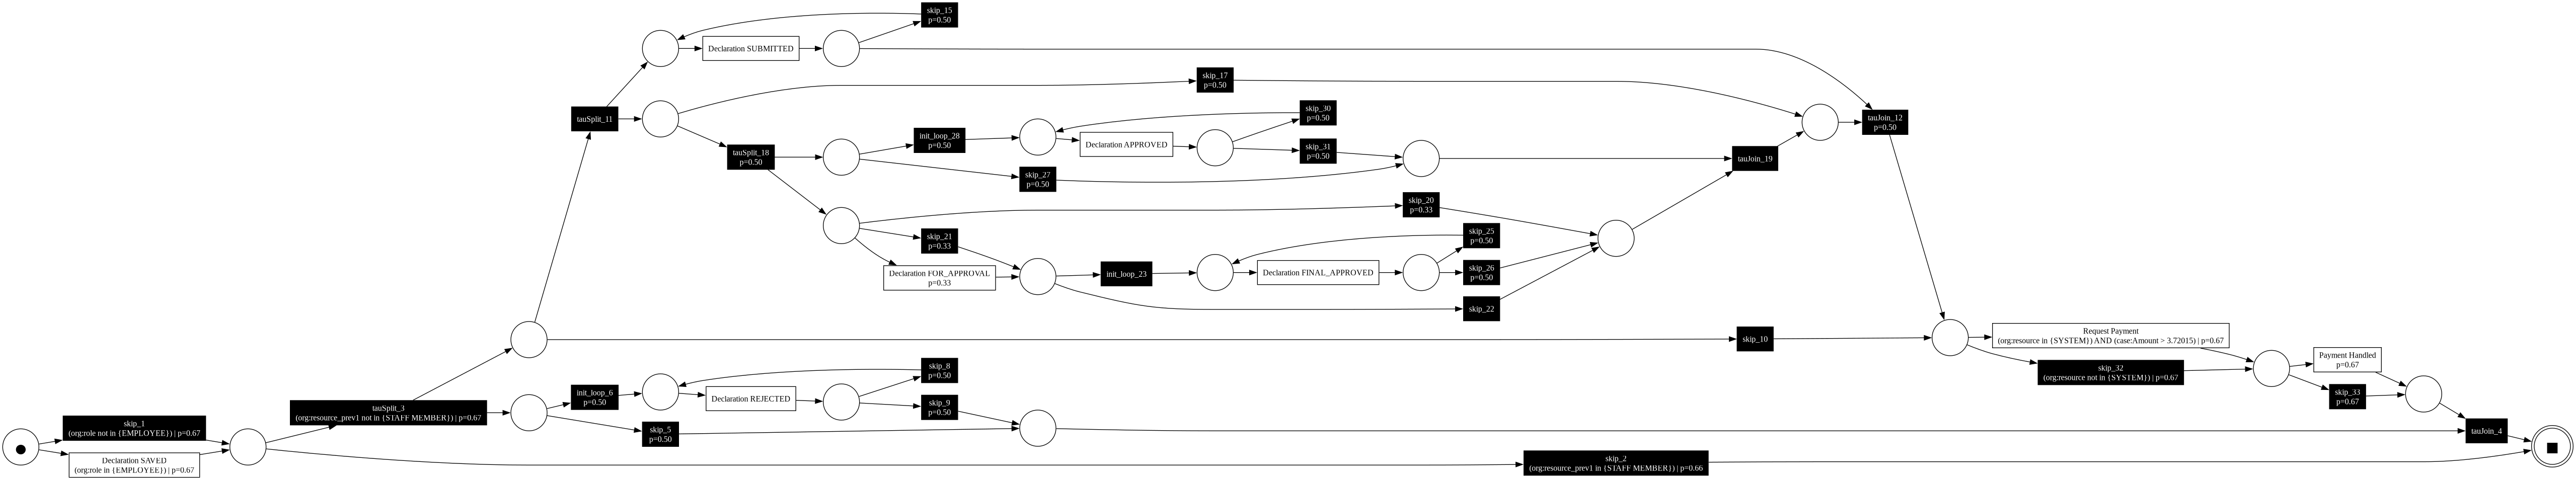

In [7]:
"""
Example:
- p=0.667; n=90; lift=27.14; rule=(Resource=nan <= 0.5)

Interpretation at this place p_X (decision point):
    - rule: the condition on prefix features that defines a leaf/region of the decision tree.
    - p: estimated probability that the target transition (the header above the guard) is chosen given the rule holds.
    - n: number of training samples (prefixes) that satisfied the rule (support).
    - lift: how much more likely that transition is under the rule compared to its baseline probability at that decision point.

Notes on empty/missing rules:
    - If you see guards with only p/n/lift and no rule, that means the simplified rule is (true).
    This can happen if the tree leaf is effectively “global” (no splits), OR if the only splits were on missingness dummy variables (e.g., Resource=nan) that we intentionally hide.
"""

dd.print_summary_and_visualize(guards=guards)